In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from brain_image.data import batch_load_images


ex_paths = ["data/things-eeg2/imgs/training_images/00001_aardvark/aardvark_01b.jpg"]

imgs = batch_load_images(ex_paths)

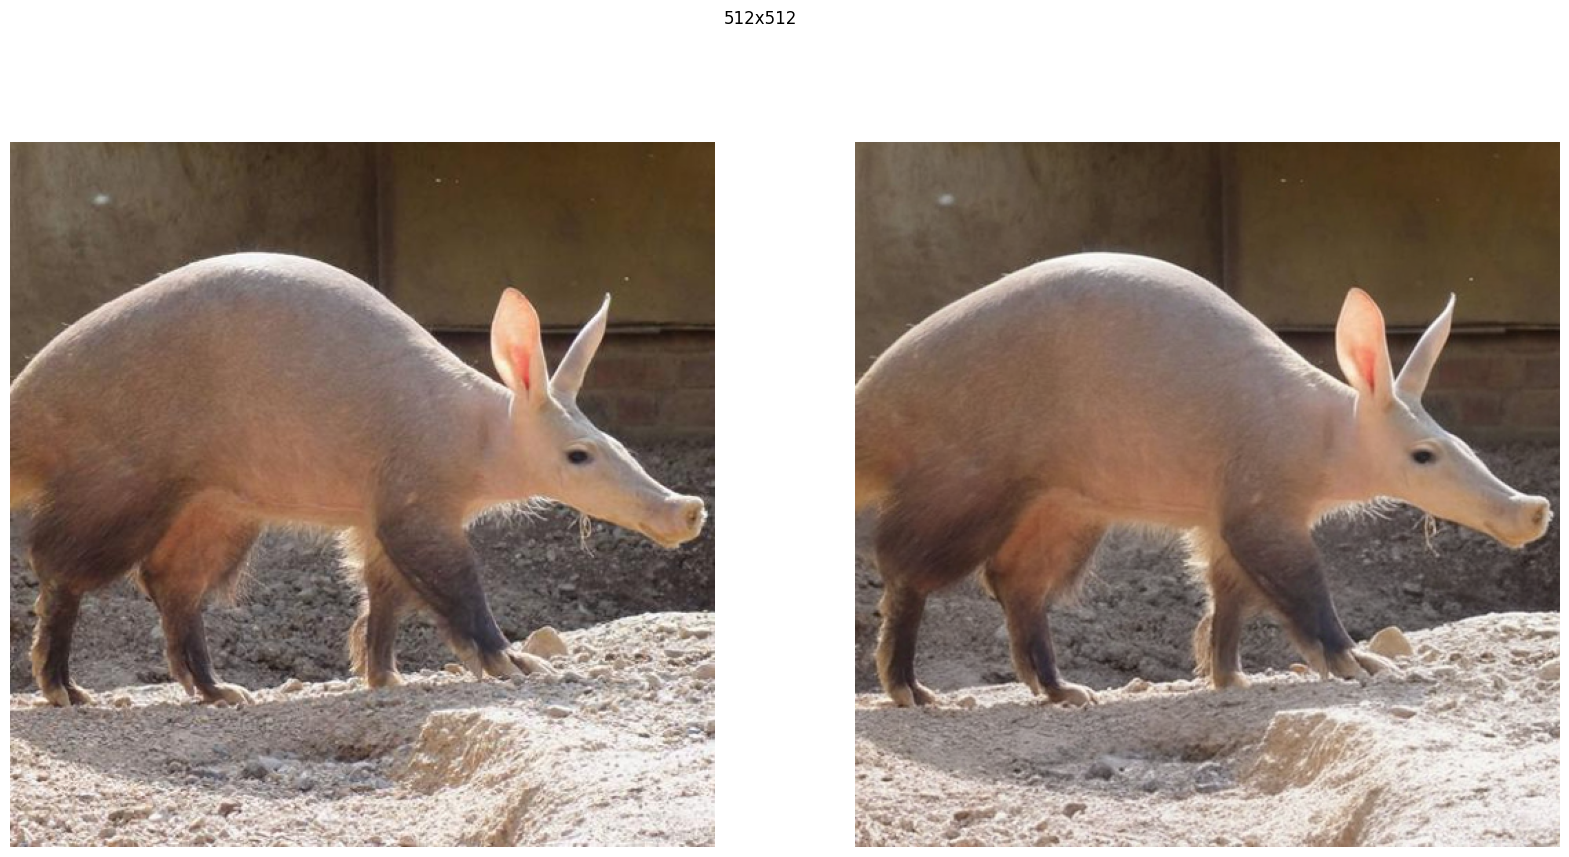

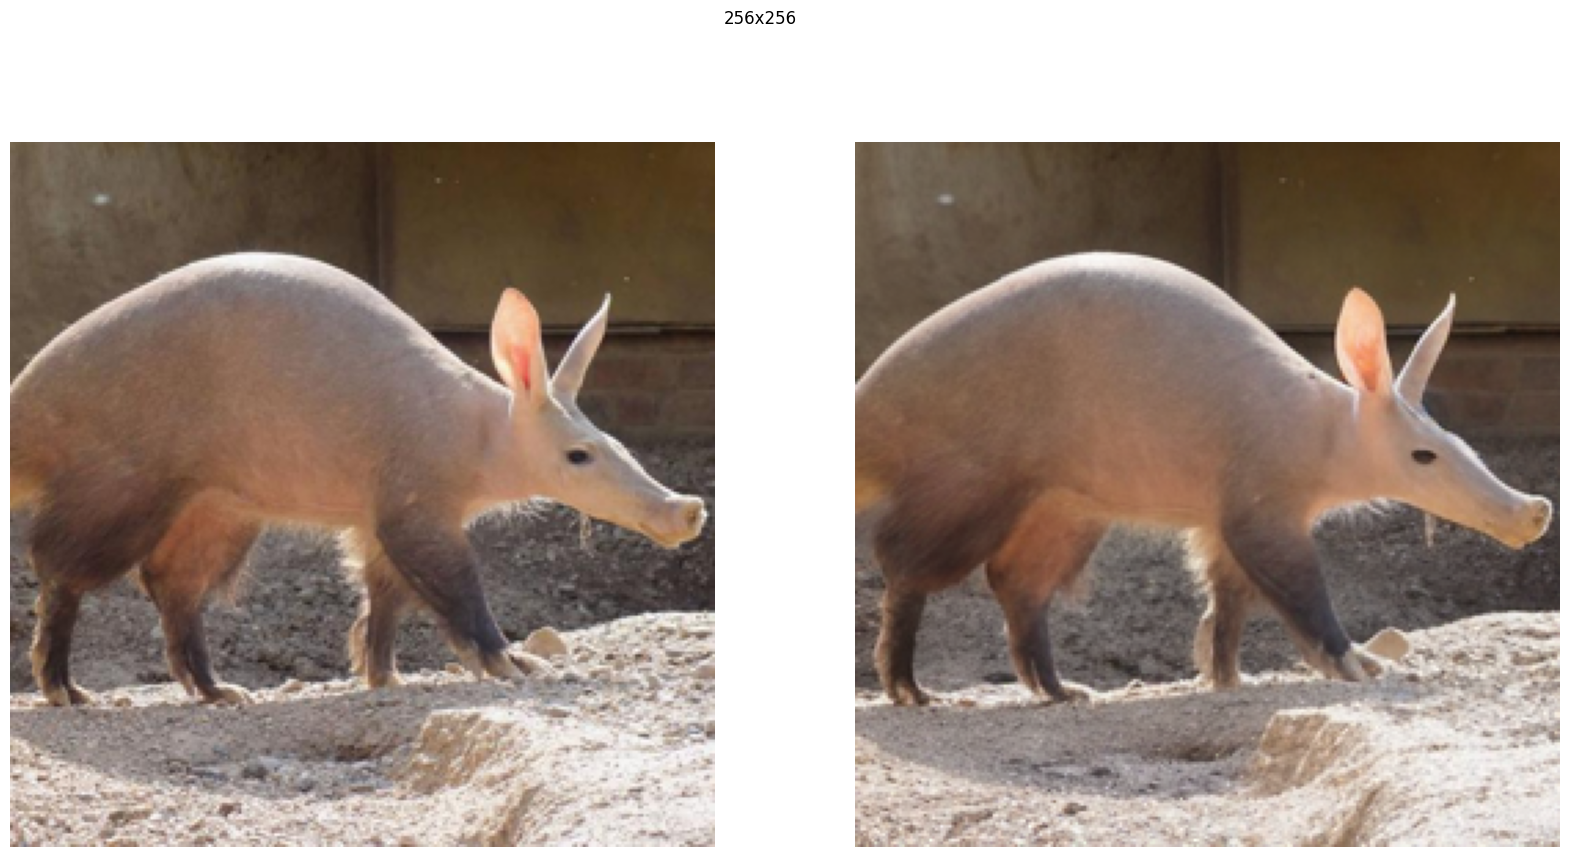

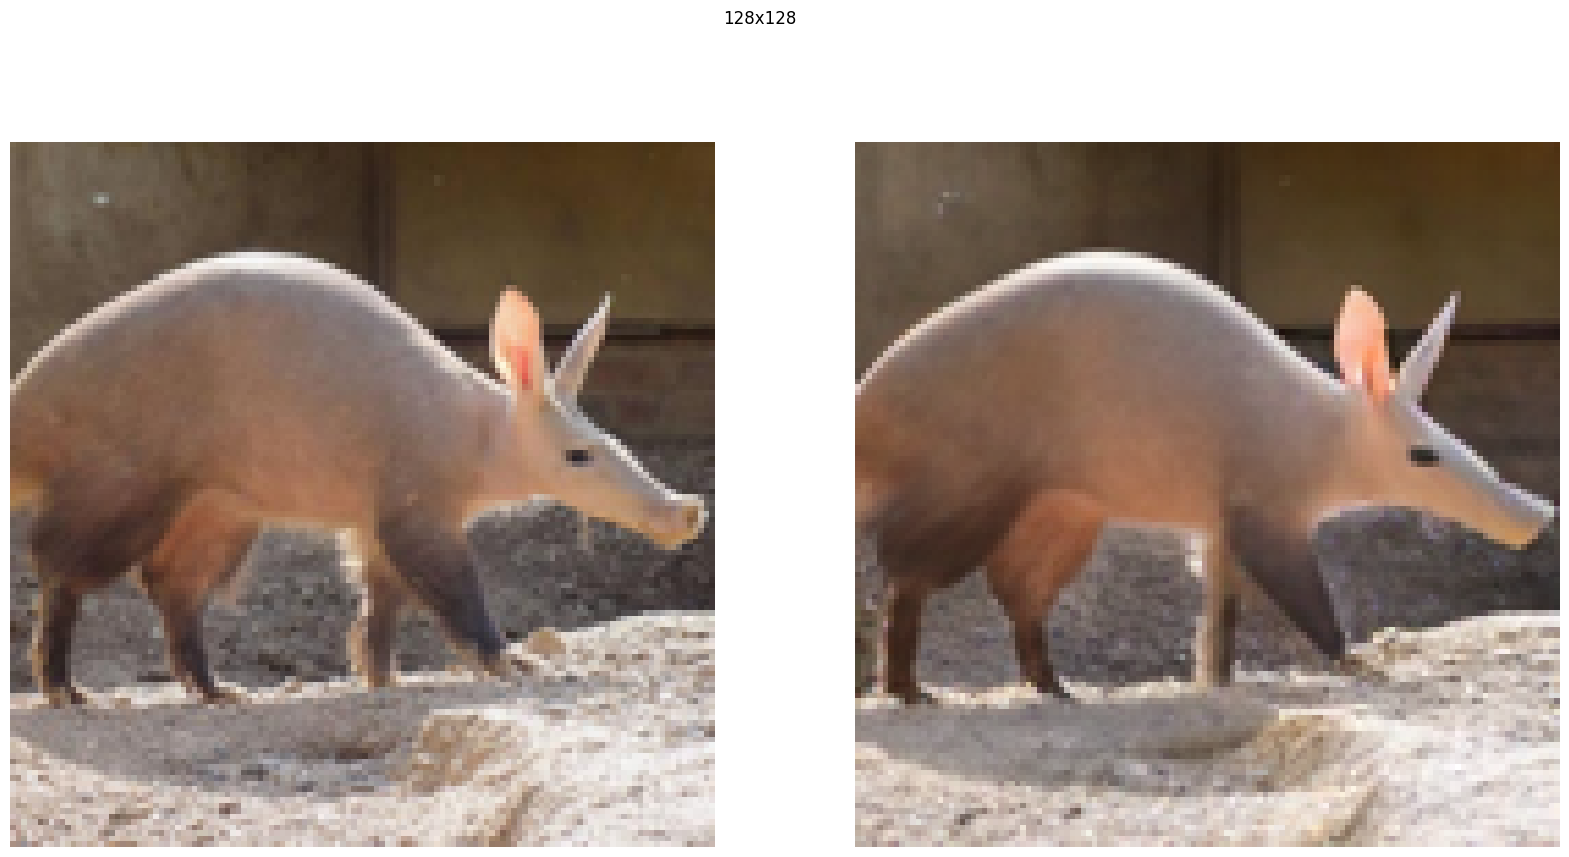

In [4]:
import torch

from brain_image.utils import show_image
from brain_image.model.img_encoder import load_vae_encoder

imgs = imgs.to("cuda")


with torch.no_grad():
    vae_128 = load_vae_encoder("ip_sdxl_turbo", img_width=128).to("cuda")
    imgs_128 = vae_128.preprocess(imgs, skip_processor=True)
    emb_128 = vae_128.encode(imgs)
    imgs_dec_128 = vae_128.decode(emb_128)

    vae_256 = load_vae_encoder("ip_sdxl_turbo", img_width=256).to("cuda")
    imgs_256 = vae_256.preprocess(imgs, skip_processor=True)
    emb_256 = vae_256.encode(imgs)
    imgs_dec_256 = vae_256.decode(emb_256)

    vae_512  = load_vae_encoder("ip_sdxl_turbo", img_width=512).to("cuda")
    imgs_512 = vae_512.preprocess(imgs, skip_processor=True)
    emb_512 = vae_512.encode(imgs)
    imgs_dec_512 = vae_512.decode(emb_512)

show_image(imgs_512, imgs_dec_512, suptitle="512x512")
show_image(imgs_256, imgs_dec_256, suptitle="256x256")
show_image(imgs_128, imgs_dec_128, suptitle="128x128")

In [ ]:


with torch.no_grad():
    print(batchify_operation(vae_256.encode, imgs_256.expand(100, -1, -1, -1), 10).shape)

0 10
10 10
20 10
30 10
40 10
50 10
60 10
70 10
80 10
90 10
torch.Size([100, 4, 32, 32])


In [ ]:
from sklearn.decomposition import PCA


for d in range(1, 16):
    pca = PCA(n_components=d)